# Import Libraries

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")
import optuna
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, average_precision_score, precision_recall_curve, auc, confusion_matrix, ConfusionMatrixDisplay)
import joblib

# Read data

In [51]:
df = pd.read_csv(r"C:\Users\Laila Khalid\Desktop\NTI\project\diabetes.csv")

# Explore data

In [52]:
print(df.shape)

(768, 9)


In [53]:
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [54]:

print(df.dtypes)

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [55]:
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

In [56]:
# biologically impossible to have 0 in Age columns
print("Searching for zeros in 'Age' column...")

if (df['Age'] == 0).sum() == 0:
    print("No zeros found in Age.")
else:
    print("Found zeros in Age.")

Searching for zeros in 'Age' column...
No zeros found in Age.


In [57]:
# biologically impossible to have 0 in DiabetesPedigreeFunction columns
print("Searching for zeros in 'DiabetesPedigreeFunction' column...")

if (df['DiabetesPedigreeFunction'] == 0).sum() == 0:
    print("No zeros found in DiabetesPedigreeFunction.")
else:
    print("Found zeros in DiabetesPedigreeFunction.")

Searching for zeros in 'DiabetesPedigreeFunction' column...
No zeros found in DiabetesPedigreeFunction.


In [58]:
df = df.drop_duplicates()
print(df.duplicated().sum())

0


In [59]:
# some columns have 0 in them, which is considered non-null, but it is biologically impossible to have them as 0, which will be fixed inwardly
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [60]:
# as a solution, we will convert the 0's for these columns to NaN
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_to_fix] = df[cols_to_fix].replace(0, np.nan)

print(df.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


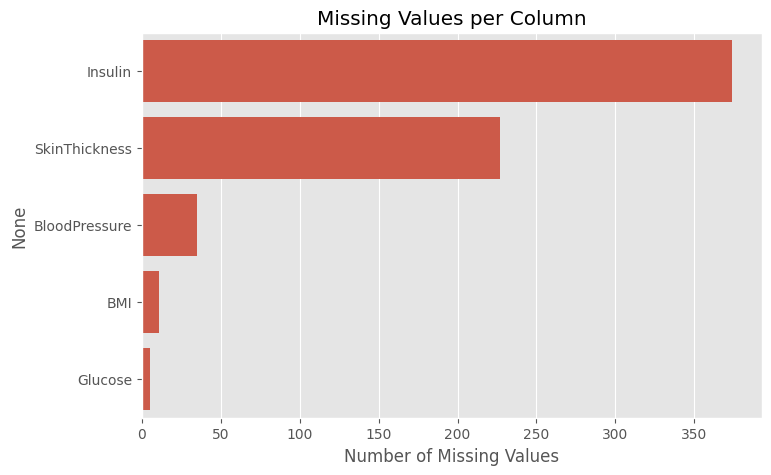

In [61]:
# plot missing values per column
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=missing_counts.values, y=missing_counts.index)
plt.title('Missing Values per Column')
plt.xlabel('Number of Missing Values')
plt.show()

# Data visualization

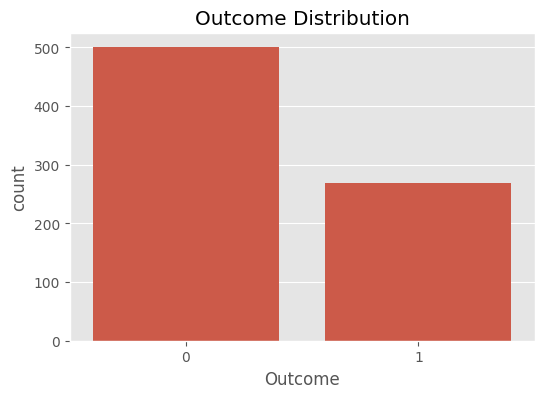

In [62]:
# outcome distribution
# Confirms class imbalance (~65% non-diabetic vs ~35% diabetic)
plt.figure(figsize=(6,4))
sns.countplot(x='Outcome', data=df)
plt.title('Outcome Distribution')
plt.show()

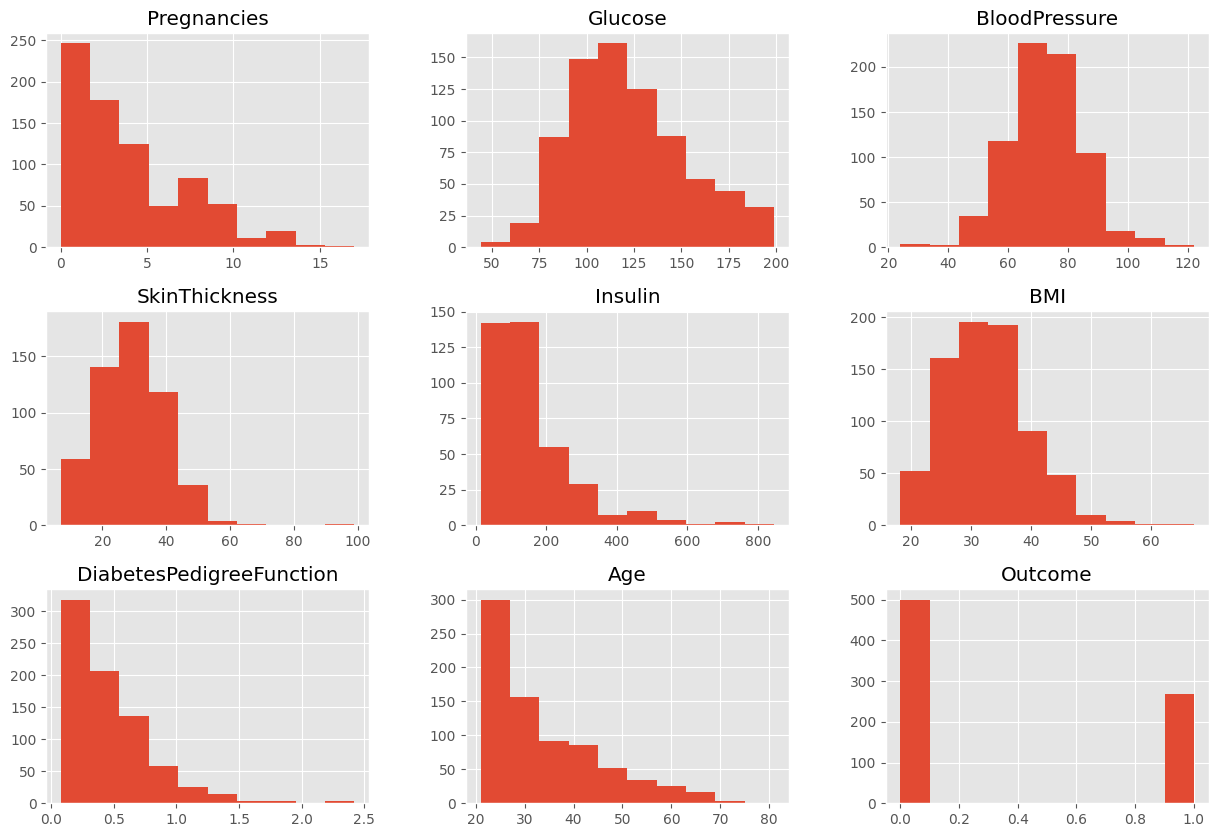

In [63]:
#histogram for all numerical columns
# Shows each feature's raw distribution and skew
df.hist(figsize=(15,10))
plt.show()

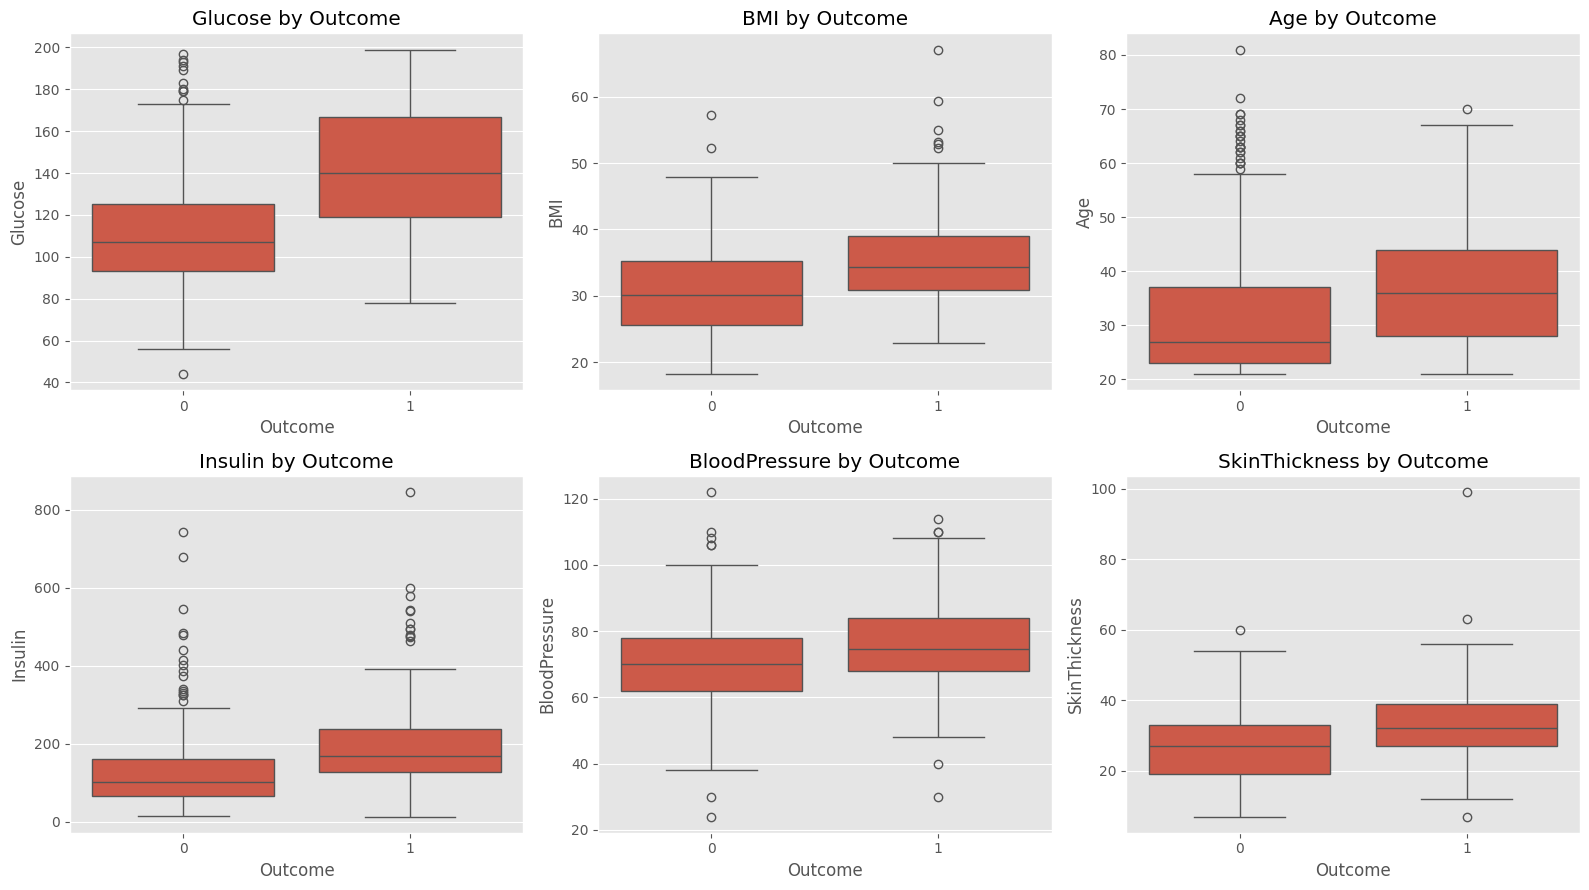

In [64]:
# boxplots of key features split by Outcome
# directly compares each feature's distribution between diabetic and non-diabetic patients, showing Glucose and BMI as the clearest visual separators
key_features = ['Glucose', 'BMI', 'Age', 'Insulin', 'BloodPressure', 'SkinThickness']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(key_features):
    sns.boxplot(data=df, x='Outcome', y=col, ax=axes[i])
    axes[i].set_title(f'{col} by Outcome')
plt.tight_layout()
plt.show()

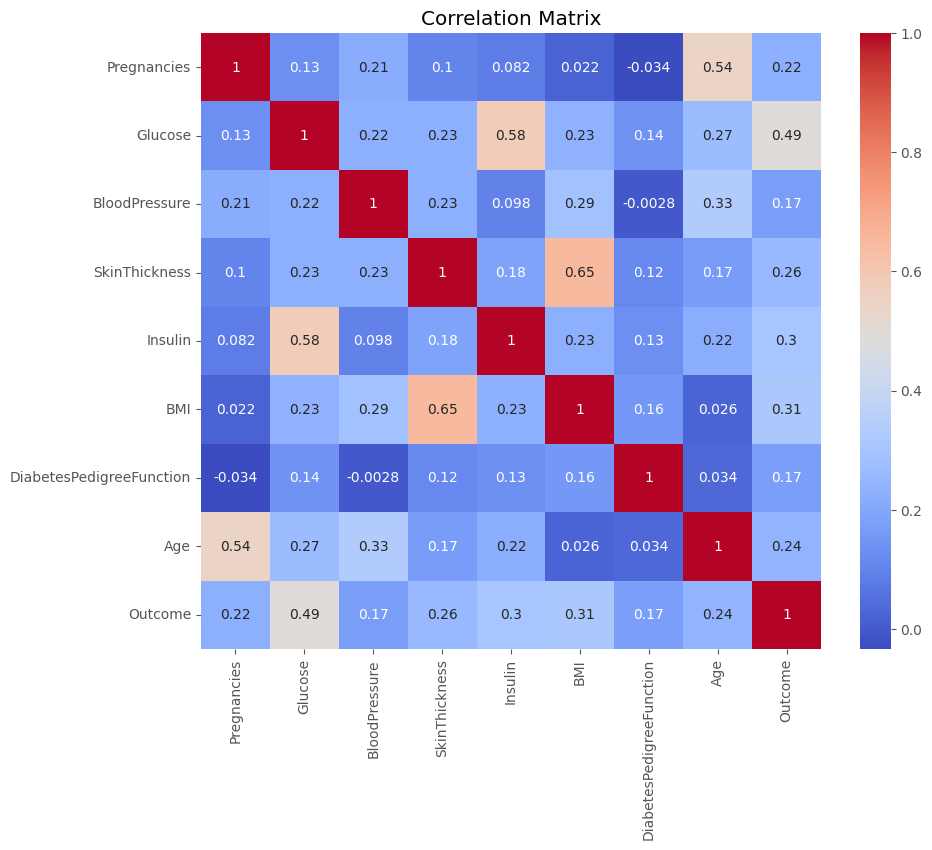

In [65]:
# correlation heatmap
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Data preprocessing

In [66]:
# must split first before any scaling to prevent data leakage
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = y, random_state=42)

In [67]:
# now that we have a lot of columns with missing values (after converting 0's to Nan); Insulin is 49% missing and SkinThickness 30%
# we will fix that issue by using simple median imputer

median_imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(median_imputer.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_imp = pd.DataFrame(median_imputer.transform(X_test), columns=X.columns, index=X_test.index)

print('Remaining missing values in train: ', X_train_imp.isnull().sum().sum(), ' test: ', X_test_imp.isnull().sum().sum())

Remaining missing values in train:  0  test:  0


In [68]:
# Scale
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=X_train_imp.columns, index=X_train_imp.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imp), columns=X_test_imp.columns, index=X_test_imp.index)

print('Train shape: ', X_train_scaled.shape, 'Test shape: ', X_test_scaled.shape)
print('Train class balance:\n', y_train.value_counts(normalize=True))

Train shape:  (614, 8) Test shape:  (154, 8)
Train class balance:
 Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64


# Model training with *Optuna*

In [69]:
# store all metrics of each algorithm for the final comparison
results = {}

# evaluation funcion that'll be called for each algorithm
def evaluate(name, y_true, y_pred, y_proba):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='macro'),
        'Recall': recall_score(y_true, y_pred, average='macro'),
        'F1': f1_score(y_true, y_pred, average='macro'),
        'ROC_AUC': roc_auc_score(y_true, y_proba),
        'PR_AUC': average_precision_score(y_true, y_proba)
    }
    print(name, {k: round(v, 4) for k, v in metrics.items()})

		# confusion matrix
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred)).plot()
    plt.title(name)
    plt.show()

    results[name] = {**metrics, 'y_pred': y_pred, 'y_proba': y_proba}

### Random Forest

[I 2026-07-23 01:06:23,152] A new study created in memory with name: no-name-ffe22f66-f14c-4fc4-874f-44b4b4e489e4
[I 2026-07-23 01:06:25,054] Trial 0 finished with value: 0.6482539682539683 and parameters: {'n_estimators': 94, 'max_depth': 11, 'min_samples_split': 5}. Best is trial 0 with value: 0.6482539682539683.
[I 2026-07-23 01:06:29,420] Trial 1 finished with value: 0.6322245236122618 and parameters: {'n_estimators': 196, 'max_depth': 20, 'min_samples_split': 6}. Best is trial 0 with value: 0.6482539682539683.
[I 2026-07-23 01:06:33,065] Trial 2 finished with value: 0.5676118849366231 and parameters: {'n_estimators': 164, 'max_depth': 3, 'min_samples_split': 5}. Best is trial 0 with value: 0.6482539682539683.
[I 2026-07-23 01:06:39,668] Trial 3 finished with value: 0.6393051976795286 and parameters: {'n_estimators': 302, 'max_depth': 12, 'min_samples_split': 10}. Best is trial 0 with value: 0.6482539682539683.
[I 2026-07-23 01:06:44,283] Trial 4 finished with value: 0.632522400655

Best params:  {'n_estimators': 143, 'max_depth': 16, 'min_samples_split': 2}
Random Forest {'Accuracy': 0.7403, 'Precision': 0.715, 'Recall': 0.6978, 'F1': 0.7038, 'ROC_AUC': 0.8214, 'PR_AUC': 0.704}


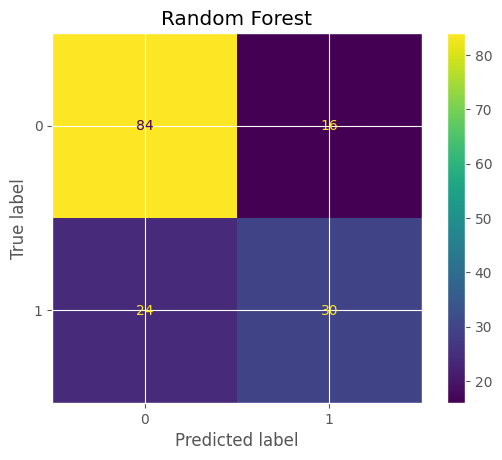

In [70]:
# objective function for hyperparameter tuning (optuna)
def objective_rf(trial):
    model = RandomForestClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 500),
        max_depth=trial.suggest_int('max_depth', 2, 20),
        min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
        random_state=42
    )
    return cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1').mean()

# create study and optimize it
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=50)
print('Best params: ', study_rf.best_params)

# fit, predict, and evaluate the model
rf = RandomForestClassifier(**study_rf.best_params, random_state=42).fit(X_train_scaled, y_train)
y_pred, y_proba = rf.predict(X_test_scaled), rf.predict_proba(X_test_scaled)[:, 1]
evaluate('Random Forest', y_test, y_pred, y_proba)

### K-Nearest Neighbor

[I 2026-07-23 01:10:04,934] A new study created in memory with name: no-name-af08a93e-d0fd-4de6-ab0f-9b651136eaf4
[I 2026-07-23 01:10:05,440] Trial 0 finished with value: 0.6492207598043006 and parameters: {'n_neighbors': 19, 'weights': 'uniform'}. Best is trial 0 with value: 0.6492207598043006.
[I 2026-07-23 01:10:05,733] Trial 1 finished with value: 0.6207758370084001 and parameters: {'n_neighbors': 25, 'weights': 'distance'}. Best is trial 0 with value: 0.6492207598043006.
[I 2026-07-23 01:10:06,004] Trial 2 finished with value: 0.6244365172636159 and parameters: {'n_neighbors': 26, 'weights': 'distance'}. Best is trial 0 with value: 0.6492207598043006.
[I 2026-07-23 01:10:06,252] Trial 3 finished with value: 0.6339155116707431 and parameters: {'n_neighbors': 9, 'weights': 'distance'}. Best is trial 0 with value: 0.6492207598043006.
[I 2026-07-23 01:10:06,506] Trial 4 finished with value: 0.6445737268506259 and parameters: {'n_neighbors': 15, 'weights': 'distance'}. Best is trial 0 

Best params:  {'n_neighbors': 17, 'weights': 'distance'}
KNN {'Accuracy': 0.7468, 'Precision': 0.7232, 'Recall': 0.7028, 'F1': 0.7097, 'ROC_AUC': 0.807, 'PR_AUC': 0.6942}


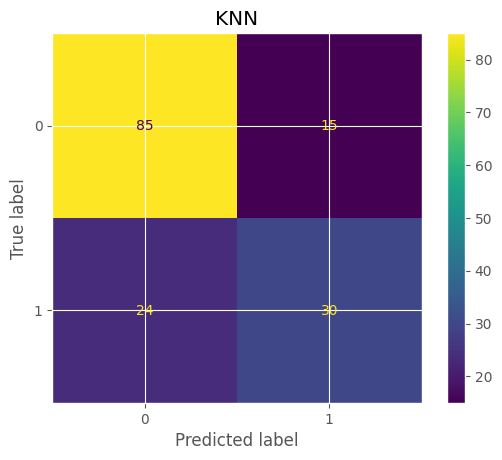

In [71]:
# objective function for hyperparameter tuning (optuna)
def objective_knn(trial):
    model = KNeighborsClassifier(
        n_neighbors=trial.suggest_int('n_neighbors', 3, 30),
        weights=trial.suggest_categorical('weights', ['uniform', 'distance'])
    )
    return cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1').mean()

# create study and optimize it
study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective_knn, n_trials=50)
print('Best params: ', study_knn.best_params)

# fit, predict, and evaluate the model
knn = KNeighborsClassifier(**study_knn.best_params).fit(X_train_scaled, y_train)
y_pred, y_proba = knn.predict(X_test_scaled), knn.predict_proba(X_test_scaled)[:, 1]
evaluate('KNN', y_test, y_pred, y_proba)

### Logistic Regression

[I 2026-07-23 01:10:16,654] A new study created in memory with name: no-name-f2e14202-763f-4cb5-97a7-457c3b2923c7
[I 2026-07-23 01:10:17,382] Trial 0 finished with value: 0.6464534405149465 and parameters: {'C': 17.804151659382633, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.6464534405149465.
[I 2026-07-23 01:10:17,742] Trial 1 finished with value: 0.6522959781386748 and parameters: {'C': 0.0038800239401299134, 'solver': 'liblinear'}. Best is trial 1 with value: 0.6522959781386748.
[I 2026-07-23 01:10:17,982] Trial 2 finished with value: 0.6464534405149465 and parameters: {'C': 22.579900575987804, 'solver': 'lbfgs'}. Best is trial 1 with value: 0.6522959781386748.
[I 2026-07-23 01:10:18,261] Trial 3 finished with value: 0.6464534405149465 and parameters: {'C': 10.205673201113923, 'solver': 'lbfgs'}. Best is trial 1 with value: 0.6522959781386748.
[I 2026-07-23 01:10:18,429] Trial 4 finished with value: 0.6355691776312424 and parameters: {'C': 0.047984087561125224, 'solver': 'lbfg

Best params:  {'C': 0.005676626125517699, 'solver': 'liblinear'}
Logistic Regression {'Accuracy': 0.7208, 'Precision': 0.6939, 'Recall': 0.6956, 'F1': 0.6947, 'ROC_AUC': 0.7959, 'PR_AUC': 0.6265}


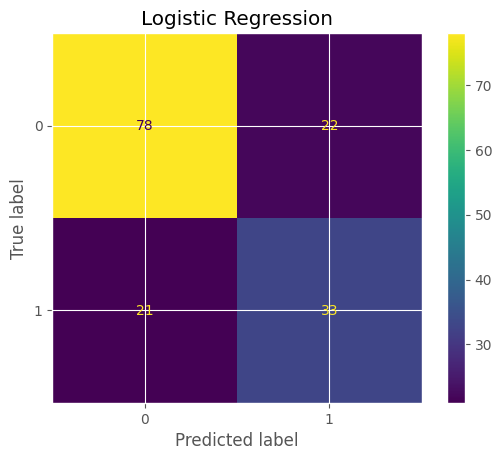

In [72]:
# objective function for hyperparameter tuning (optuna)
def objective_logistic(trial):
    model = LogisticRegression(
        C=trial.suggest_float('C', 0.001, 100, log=True),
        solver=trial.suggest_categorical('solver', ['liblinear', 'lbfgs']),
        max_iter=1000,
        random_state=42
    )
    return cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring='f1'
    ).mean()

# create study and optimize it
study_logistic = optuna.create_study(direction='maximize')
study_logistic.optimize(objective_logistic, n_trials=50)
print('Best params: ', study_logistic.best_params)

# fit, predict, and evaluate the model
logistic = LogisticRegression(**study_logistic.best_params, max_iter=1000, random_state=42).fit(X_train_scaled, y_train)
y_pred, y_proba = logistic.predict(X_test_scaled), logistic.predict_proba(X_test_scaled)[:, 1]
evaluate('Logistic Regression', y_test, y_pred, y_proba)


SVM

[I 2026-07-23 01:10:26,910] A new study created in memory with name: no-name-4b074f4d-a3ce-4e74-a370-3aa7306ed2ee
[I 2026-07-23 01:10:27,799] Trial 0 finished with value: 0.6091405941923196 and parameters: {'C': 6.1130938512058135, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 0 with value: 0.6091405941923196.
[I 2026-07-23 01:10:28,095] Trial 1 finished with value: 0.6080121457131582 and parameters: {'C': 0.02527681944444257, 'kernel': 'linear', 'gamma': 'auto'}. Best is trial 0 with value: 0.6091405941923196.
[I 2026-07-23 01:10:28,435] Trial 2 finished with value: 0.6268736397956918 and parameters: {'C': 0.6117841894498746, 'kernel': 'linear', 'gamma': 'scale'}. Best is trial 2 with value: 0.6268736397956918.
[I 2026-07-23 01:10:29,089] Trial 3 finished with value: 0.5968342955959054 and parameters: {'C': 0.20554154901358768, 'kernel': 'rbf', 'gamma': 'auto'}. Best is trial 2 with value: 0.6268736397956918.
[I 2026-07-23 01:10:34,052] Trial 4 finished with value: 0.6236231319038

Best params: {'C': 0.28354379782154604, 'kernel': 'linear', 'gamma': 'scale'}
SVM {'Accuracy': 0.7078, 'Precision': 0.6762, 'Recall': 0.6557, 'F1': 0.6614, 'ROC_AUC': 0.8122, 'PR_AUC': 0.6715}


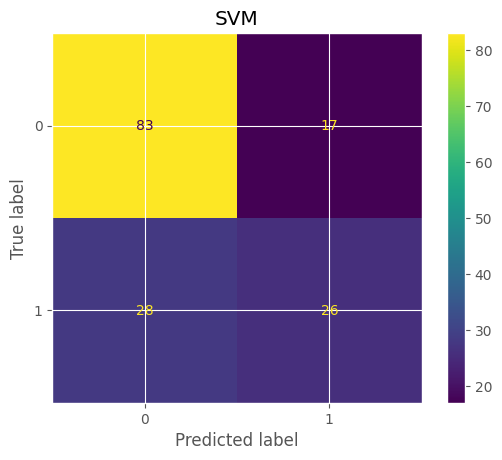

In [73]:
# objective function for hyperparameter tuning (optuna)
def objective_svm(trial):
    model = SVC(
        C=trial.suggest_float('C', 0.01, 100, log=True),
        kernel=trial.suggest_categorical('kernel', ['linear', 'rbf']),
        gamma=trial.suggest_categorical('gamma', ['scale', 'auto']),
        probability=True,
        random_state=42
    )

    return cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring='f1'
    ).mean()

# create study and optimize it
study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=50)

print('Best params:', study_svm.best_params)

# fit, predict, and evaluate the model
svm = SVC(**study_svm.best_params, probability=True, random_state=42).fit(X_train_scaled, y_train)
y_pred, y_proba = svm.predict(X_test_scaled), svm.predict_proba(X_test_scaled)[:, 1]
evaluate('SVM', y_test, y_pred, y_proba)

# Final Comparison & Evaluation

                     Accuracy  Precision    Recall        F1   ROC_AUC  \
KNN                  0.746753   0.723242  0.702778  0.709729  0.807037   
Random Forest        0.740260   0.714976  0.697778  0.703846  0.821389   
Logistic Regression  0.720779   0.693939  0.695556  0.694712  0.795926   
SVM                  0.707792   0.676199  0.655741  0.661406  0.812222   

                       PR_AUC  
KNN                  0.694217  
Random Forest        0.703957  
Logistic Regression  0.626529  
SVM                  0.671501  


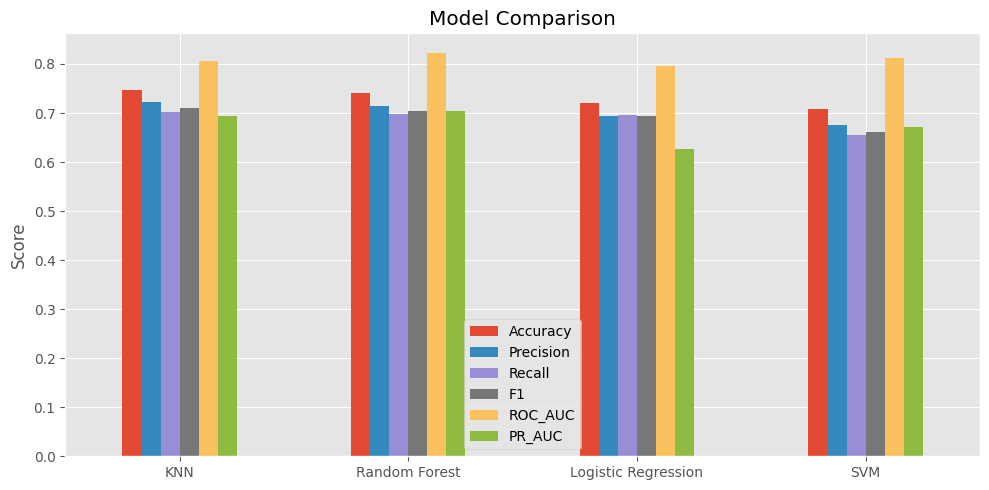

In [74]:
comparison_df = pd.DataFrame(results).T.drop(columns=['y_pred', 'y_proba'])
comparison_df = comparison_df.astype(float).sort_values('F1', ascending=False)
print(comparison_df)

comparison_df.plot(kind='bar', figsize=(10, 5))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

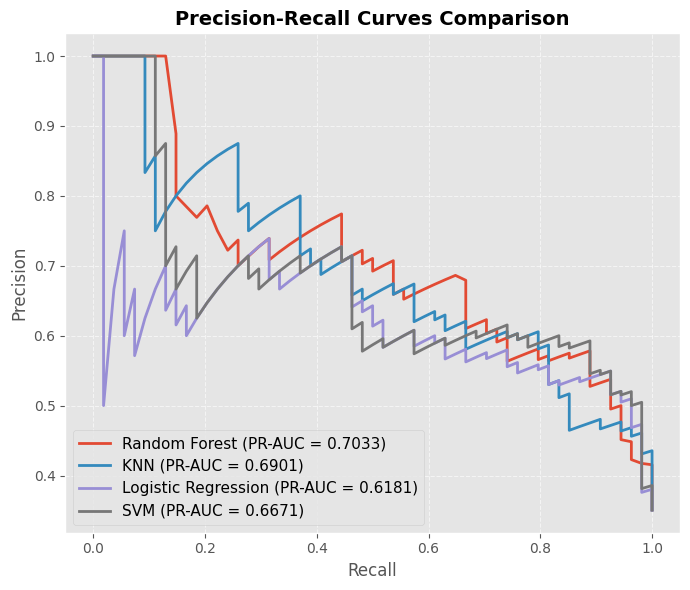

In [75]:
plt.figure(figsize=(7, 6))
for name, metrics in results.items():
    precision, recall, _ = precision_recall_curve(y_test, metrics['y_proba'])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, linewidth=2, label=f"{name} (PR-AUC = {pr_auc:.4f})")

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

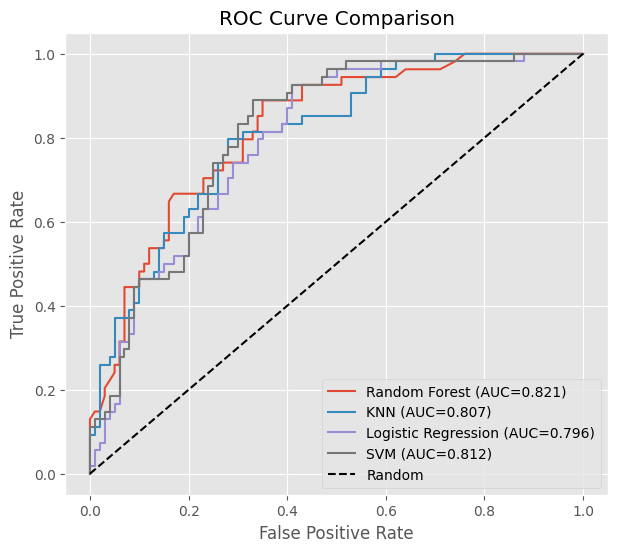

In [76]:
plt.figure(figsize=(7, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['ROC_AUC']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

# Save models for the Deployment

In [77]:
# package everything the GUI needs, using the variables already defined above
artifact = {
    'imputer': median_imputer,
    'scaler': scaler,
    'models': {
        'Logistic Regression': logistic,
        'KNN': knn,
        'Random Forest': rf,
        'SVM': svm,
    },
    'feature_columns': list(X_train_imp.columns),
    'raw_columns': list(X.columns),
}

joblib.dump(artifact, 'diabetes_model.pkl')
print('Saved diabetes_model.pkl')

Saved diabetes_model.pkl


# Deployment using Streamlit

In [78]:
import streamlit as st
import joblib
import pandas as pd
import numpy as np

st.set_page_config(page_title='Diabetes Risk Predictor', page_icon='🩺', layout='centered')

artifact = joblib.load('diabetes_model.pkl')

FIELDS = [
    ('Pregnancies', 1, 0, 20),
    ('Glucose', 120, 0, 300),
    ('BloodPressure', 70, 0, 150),
    ('SkinThickness', 20, 0, 100),
    ('Insulin', 80, 0, 1000),
    ('BMI', 25.0, 0, 70),
    ('DiabetesPedigreeFunction', 0.5, 0.0, 3.0),
    ('Age', 30, 0, 120),
]
INT_FIELDS = {'Pregnancies', 'Age'}
ZERO_AS_MISSING = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']


def predict_with(model_name, values):
    raw = pd.DataFrame([values])[artifact['raw_columns']]
    raw[ZERO_AS_MISSING] = raw[ZERO_AS_MISSING].replace(0, np.nan)
    imputed = pd.DataFrame(artifact['imputer'].transform(raw), columns=artifact['raw_columns'])
    scaled = artifact['scaler'].transform(imputed)
    model = artifact['models'][model_name]
    prediction = model.predict(scaled)[0]
    probability = model.predict_proba(scaled)[0][1]
    return prediction, probability


st.title('Diabetes Risk Predictor')

model_name = st.selectbox('Choose a model', list(artifact['models']))

values = {}
for name, default, min_val, max_val in FIELDS:
    if name in INT_FIELDS:
        values[name] = st.slider(name, int(min_val), int(max_val), int(default))
    else:
        values[name] = st.slider(name, float(min_val), float(max_val), float(default), step=0.1)

if st.button('Predict', type='primary', use_container_width=True):
    prediction, probability = predict_with(model_name, values)
    if prediction == 1:
        st.error(f'Higher risk of diabetes  ({probability:.1%})')
    else:
        st.success(f'Lower risk of diabetes  ({probability:.1%})')
    st.caption('This is a model estimate, not a medical diagnosis.')

2026-07-23 01:11:16.674 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 01:11:17.080 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 01:11:17.082 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 01:11:17.089 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 01:11:17.096 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 01:11:17.099 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 01:11:17.102 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 01:11:17.107 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar